In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
pd.set_option('display.max_columns', None)
from sklearn.svm import OneClassSVM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("/content/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [10]:
from sklearn.utils import resample

df_majority = df[df['Class'] == 0]
df_minority = df[df['Class'] == 1]

df_majority_downsampled = resample(df_majority, replace=False, n_samples=10000, random_state=42)
df_minority_upsampled = resample(df_minority, replace=True, n_samples=10000, random_state=42)

df_resampled = pd.concat([df_majority_downsampled, df_minority_upsampled])
df = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)
df["Class"].value_counts()

,count
Class,
1,10000
0,10000


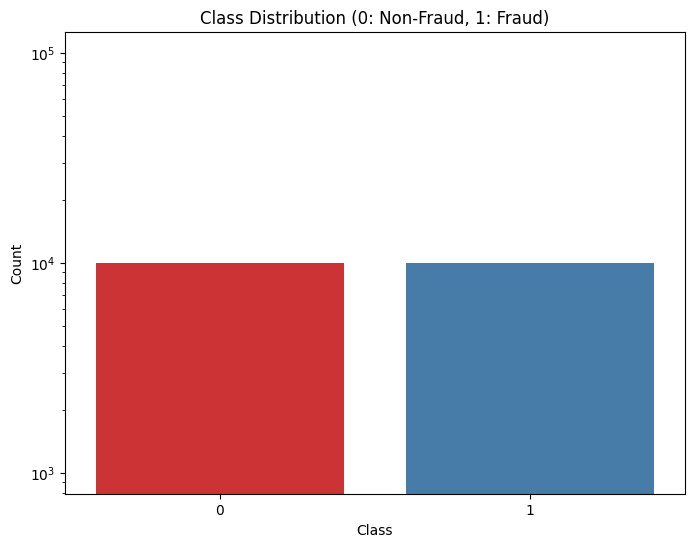

In [11]:

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df,palette="Set1")
plt.title('Class Distribution (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.yscale('log')  # Log scale for class imbalance
plt.savefig('class_distribution.png')
plt.show()

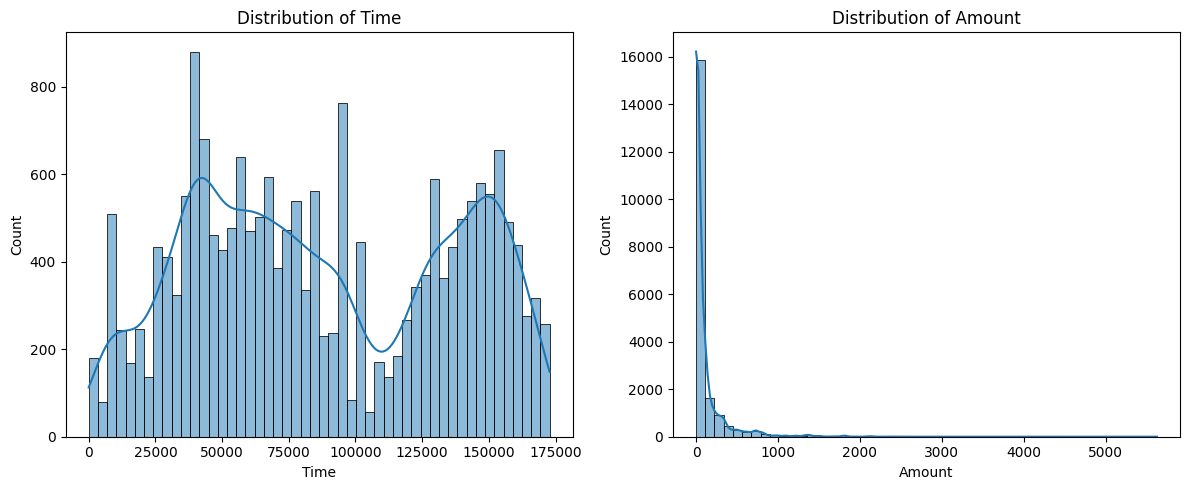

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Distribution of Time')
plt.subplot(1, 2, 2)
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Amount')
plt.tight_layout()
plt.savefig('time_amount_hist.png')
plt.show()

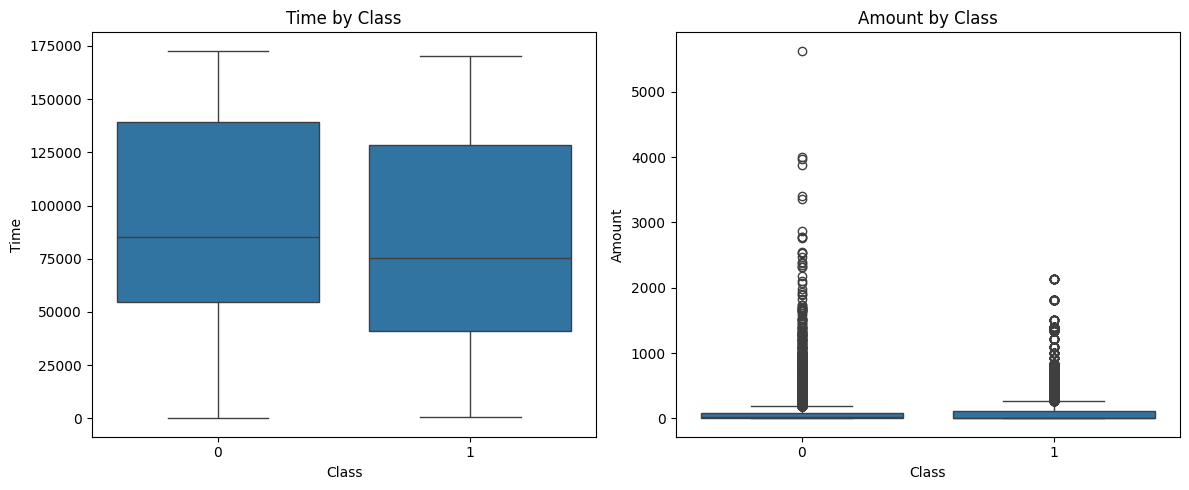

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Class', y='Time', data=df)
plt.title('Time by Class')
plt.subplot(1, 2, 2)
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount by Class')
plt.tight_layout()
plt.savefig('boxplots_time_amount.png')
plt.show()

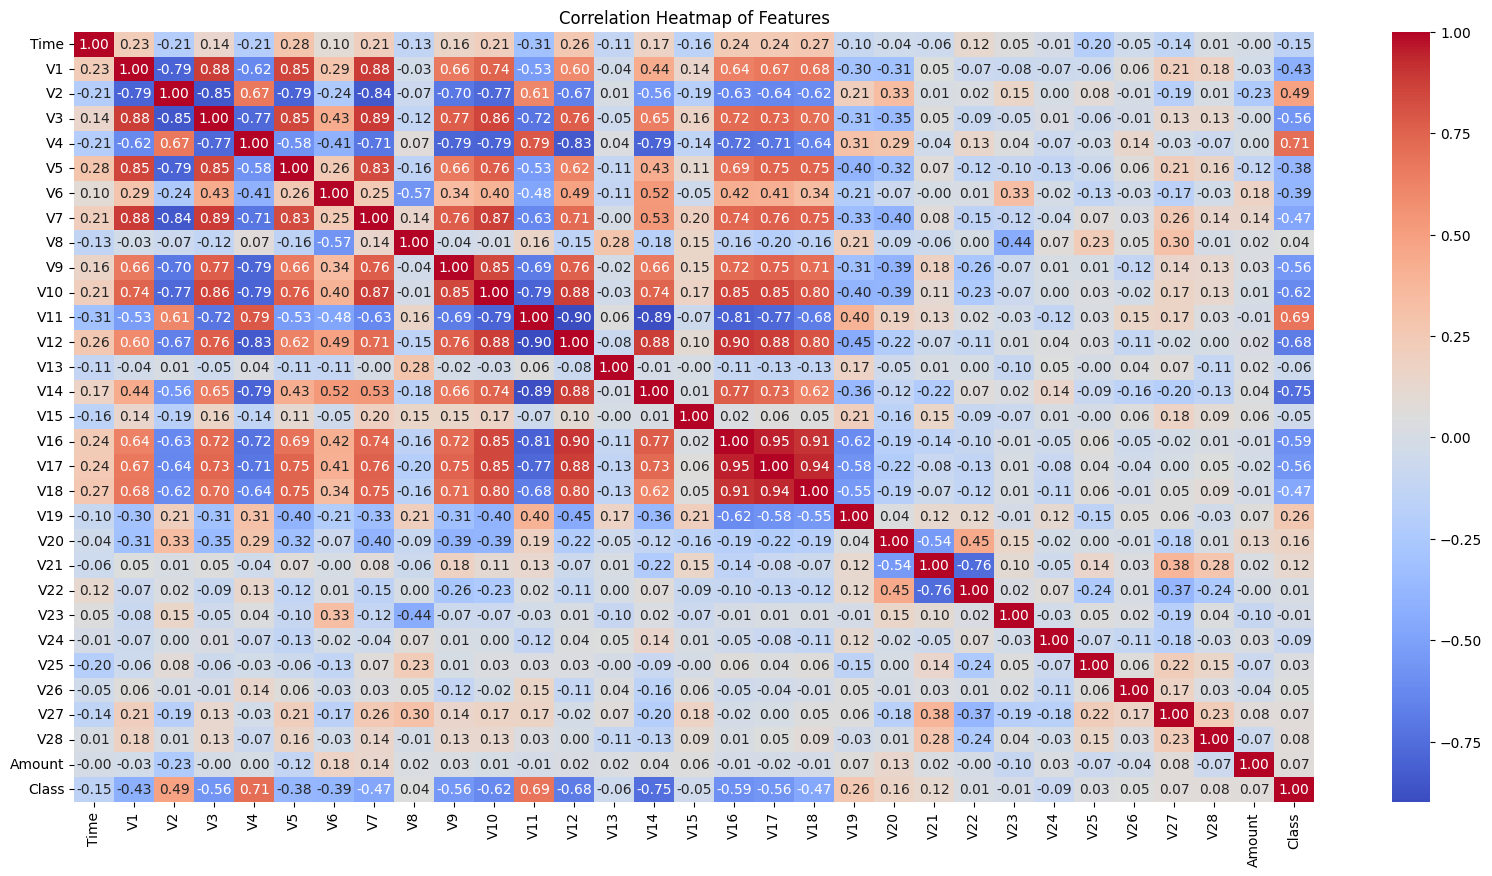

In [14]:
plt.figure(figsize=(20, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True,fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

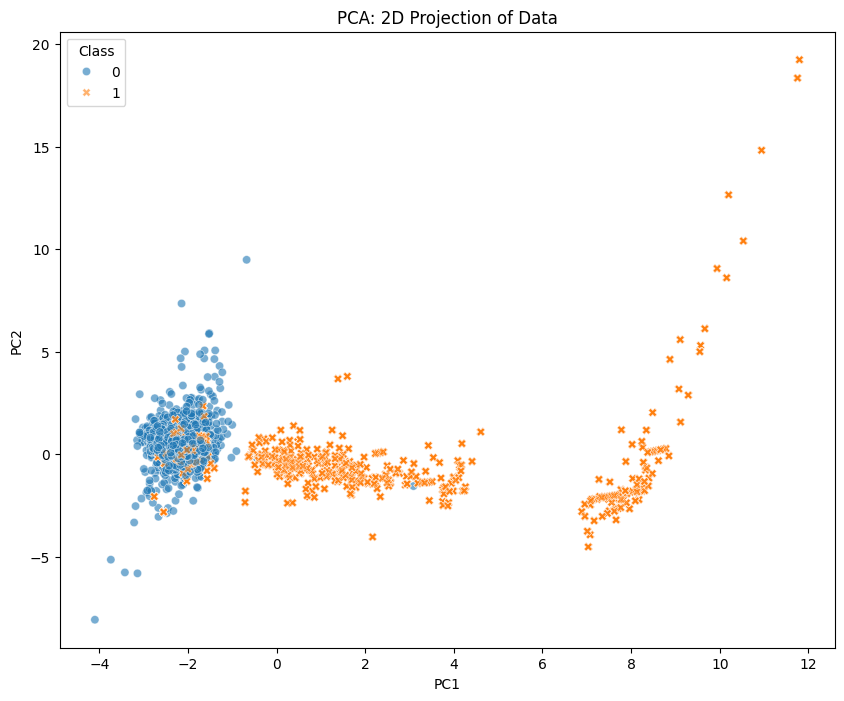

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('Class', axis=1))
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Class'] = df['Class'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Class', style='Class', data=pca_df, alpha=0.6)
plt.title('PCA: 2D Projection of Data')
plt.show()

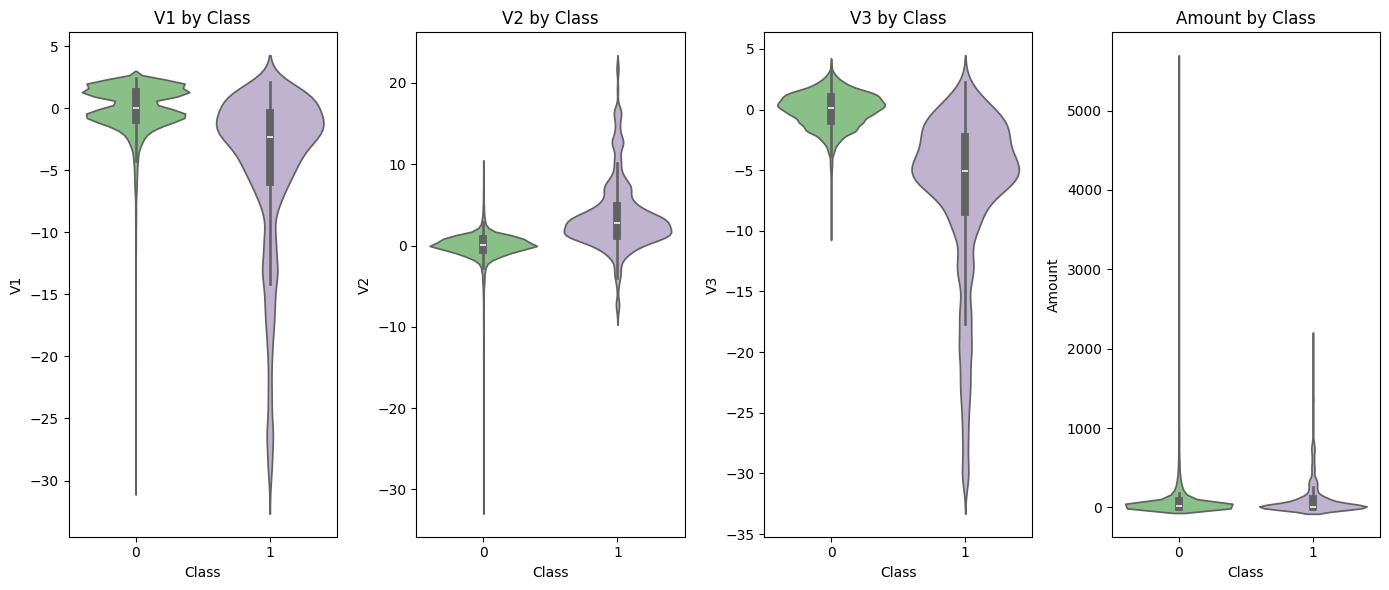

In [16]:
plt.figure(figsize=(14, 6))
for i, col in enumerate(['V1', 'V2', 'V3', 'Amount'], 1):
    plt.subplot(1, 4, i)
    sns.violinplot(x='Class', y=col, data=df,palette="Accent")
    plt.title(f'{col} by Class')
plt.tight_layout()
plt.show()

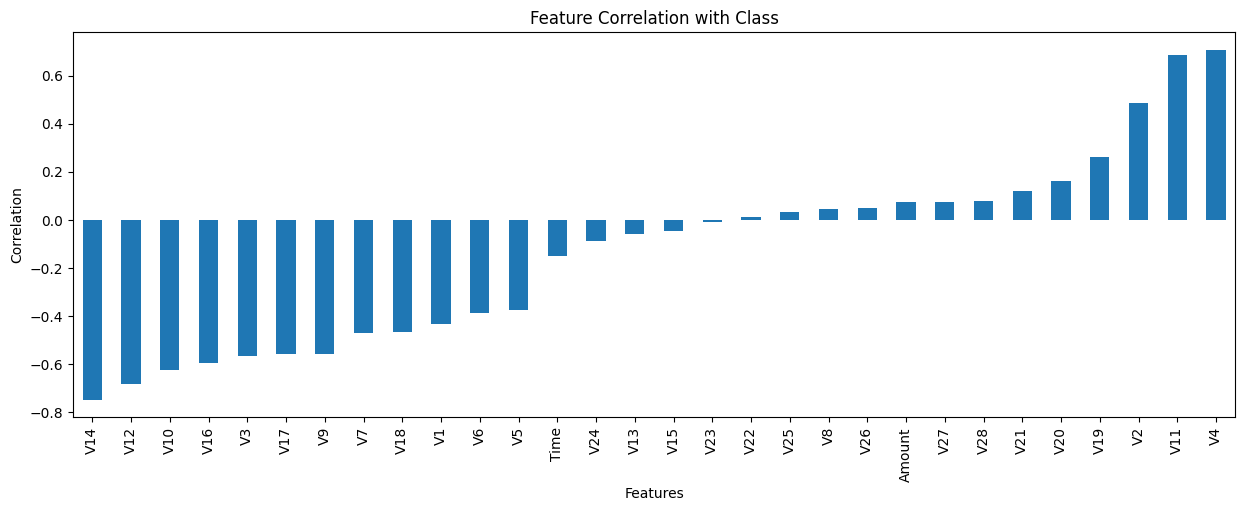

In [17]:
correlations = df.corr()['Class'].drop('Class').sort_values()
correlations.plot(kind='bar',figsize=(15,5))
plt.title('Feature Correlation with Class')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

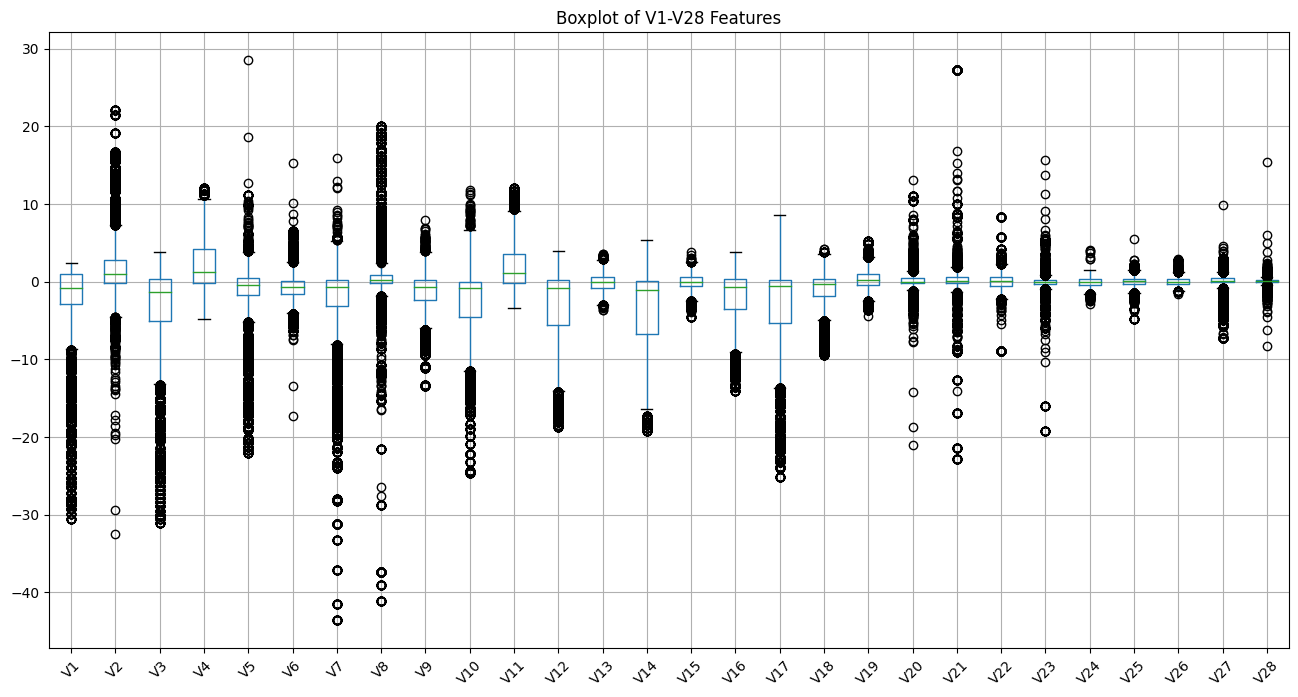

In [18]:
plt.figure(figsize=(16, 8))
df.drop(['Time', 'Amount', 'Class'], axis=1).boxplot()
plt.title('Boxplot of V1-V28 Features')
plt.xticks(rotation=45)
plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = [col for col in df.columns if col not in ['Time', 'Class']]
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [20]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,76867.0,0.960075,0.615731,0.852691,0.402415,0.450667,0.505259,0.734942,0.674883,0.629306,0.623356,0.390436,0.811431,0.261390,0.600919,0.516328,0.846845,0.864467,0.819423,0.363305,0.611781,0.449442,0.472646,0.548950,0.381094,0.518325,0.273097,0.428890,0.355570,0.000178,1
1,118768.0,0.991099,0.583427,0.861352,0.251535,0.420098,0.499036,0.718269,0.669304,0.628094,0.677777,0.207446,0.804428,0.605200,0.691386,0.575434,0.876571,0.788033,0.647815,0.468680,0.618272,0.461106,0.563996,0.554575,0.396187,0.448739,0.329664,0.425616,0.350464,0.005753,0
2,152882.0,0.923559,0.616192,0.886107,0.265899,0.454526,0.494064,0.755736,0.661849,0.630001,0.659103,0.185105,0.808310,0.522254,0.736632,0.622026,0.783224,0.754864,0.743224,0.452848,0.614322,0.462032,0.580012,0.543129,0.390337,0.413913,0.301838,0.412314,0.351888,0.004297,0
3,85077.0,0.898095,0.606640,0.893153,0.276417,0.442940,0.685973,0.709042,0.670284,0.566050,0.693012,0.164920,0.812143,0.572808,0.784812,0.687950,0.707617,0.753336,0.868667,0.546180,0.596437,0.482903,0.486342,0.555994,0.556244,0.442708,0.345227,0.441080,0.353144,0.025768,0
4,30852.0,0.841304,0.611896,0.926297,0.452621,0.443032,0.538924,0.762110,0.632142,0.632108,0.765570,0.265411,0.795185,0.476761,0.743798,0.728166,0.730848,0.747303,0.622740,0.505625,0.585975,0.466880,0.534639,0.556944,0.504922,0.412129,0.331314,0.275969,0.363966,0.018626,1


In [21]:
from sklearn.model_selection import train_test_split
X=df.drop('Class',axis=1)
y=df['Class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
iso_model= IsolationForest(n_estimators=1000, max_samples=len(X_train),random_state=42, verbose=1)
iso_model.fit(X_train,y_train)

IsolationForest(max_samples=16000, n_estimators=1000, random_state=42,
                verbose=1)

In [23]:
from sklearn.metrics import f1_score, precision_score, recall_score
y_pred=iso_model.predict(X_test)
y_pred=np.where(y_pred==-1,1,0)
print(accuracy_score(y_test,y_pred))
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

0.55775
F1 Score: 0.1753
Precision: 0.9400
Recall: 0.0967


In [24]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.54      0.99      0.70      2055
           1       0.94      0.10      0.18      1945

    accuracy                           0.56      4000
   macro avg       0.74      0.55      0.44      4000
weighted avg       0.73      0.56      0.44      4000



In [25]:
n_errors = (y_pred != y_test).sum()
print("Isolation Forest have {} errors.".format(n_errors))

Isolation Forest have 1769 errors.


In [26]:
# svm= OneClassSVM(kernel='rbf', degree=3, gamma=0.1,nu=0.05,verbose=1)
# svm.fit(X_train,y_train)

In [27]:
!pip install pycaret

In [28]:
df=pd.read_csv("/content/creditcard.csv")

In [29]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [30]:
df_majority = df[df['Class'] == 0]
df_minority = df[df['Class'] == 1]

df_majority_downsampled = resample(df_majority, replace=False, n_samples=10000, random_state=42)
df_minority_upsampled = resample(df_minority, replace=True, n_samples=10000, random_state=42)

df_resampled = pd.concat([df_majority_downsampled, df_minority_upsampled])
df = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)
df["Class"].value_counts()

,count
Class,
1,10000
0,10000


In [31]:
from pycaret.classification import *
s = setup(data=df, target = 'Class', session_id = 123)

,Description,Value
0,Session id,123
1,Target,Class
2,Target type,Binary
3,Original data shape,"(20000, 31)"
4,Transformed data shape,"(20000, 31)"
5,Transformed train set shape,"(14000, 31)"
6,Transformed test set shape,"(6000, 31)"
7,Numeric features,30
8,Preprocess,True
9,Imputation type,simple


In [32]:
best=compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9995,0.9999,1.0000,0.9990,0.9995,0.9990,0.9990,0.9150
rf,Random Forest Classifier,0.9994,0.9999,1.0000,0.9989,0.9994,0.9989,0.9989,4.0730
lightgbm,Light Gradient Boosting Machine,0.9989,0.9999,1.0000,0.9979,0.9989,0.9979,0.9979,5.4860
xgboost,Extreme Gradient Boosting,0.9984,0.9999,1.0000,0.9969,0.9984,0.9969,0.9969,0.5680
dt,Decision Tree Classifier,0.9951,0.9951,1.0000,0.9903,0.9951,0.9901,0.9902,0.7150
gbc,Gradient Boosting Classifier,0.9904,0.9991,0.9913,0.9896,0.9904,0.9809,0.9809,10.0230
ada,Ada Boost Classifier,0.9657,0.9971,0.9540,0.9770,0.9653,0.9314,0.9318,2.1420
lr,Logistic Regression,0.9465,0.9856,0.9210,0.9706,0.9451,0.8930,0.8942,3.1420
knn,K Neighbors Classifier,0.9326,0.9770,1.0000,0.8813,0.9369,0.8653,0.8733,0.5660
qda,Quadratic Discriminant Analysis,0.9246,0.9761,0.8863,0.9599,0.9216,0.8491,0.8517,0.0620


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [36]:
tuned_model= tune_model(best)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9479,0.9918,0.8986,0.9968,0.9452,0.8957,0.9001
1,0.9529,0.9956,0.9071,0.9984,0.9506,0.9057,0.9095
2,0.9507,0.9916,0.9029,0.9984,0.9482,0.9014,0.9056
3,0.9443,0.9937,0.8929,0.9952,0.9413,0.8886,0.8933
4,0.9421,0.9890,0.8886,0.9952,0.9389,0.8843,0.8894
5,0.9471,0.9905,0.9014,0.9921,0.9446,0.8943,0.8980
6,0.9543,0.9921,0.9143,0.9938,0.9524,0.9086,0.9115
7,0.9429,0.9936,0.8914,0.9936,0.9398,0.8857,0.8904
8,0.9450,0.9900,0.8971,0.9921,0.9422,0.8900,0.8941


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [38]:
holdout_pred = predict_model(best)
holdout_pred.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9997,1.0000,1.0000,0.9993,0.9997,0.9993,0.9993


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,prediction_label,prediction_score
1588,36408.0,0.952604,-0.719910,-0.526808,0.348708,-0.086302,-0.067188,0.360079,-0.235861,-1.391670,...,-0.111137,-0.831422,0.379134,-0.605178,0.001322,0.053528,228.889999,0,0,0.99
1226,138868.0,0.258459,1.315522,-1.158684,0.434192,1.798168,-0.614591,1.440162,-0.224183,-0.511905,...,-0.304794,0.139950,0.325506,-0.567408,0.041936,0.024902,1.000000,0,0,0.95
8459,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382712,...,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.250000,1,1,1.00
14121,76575.0,-5.622469,3.480623,-6.200676,4.311234,-5.226286,-1.341764,-5.220941,2.682843,-2.921484,...,-0.350675,0.197550,0.159234,-0.377791,-0.213562,0.459529,219.800003,1,1,1.00
571,26556.0,-19.179827,11.817922,-21.919174,6.086236,-14.708845,-4.308887,-15.357952,12.857165,-3.999861,...,-0.762965,0.117028,1.297994,-0.224825,1.621052,0.484614,99.989998,1,1,1.00


In [39]:
new_data = pd.read_csv('/content/creditcard.csv')
new_data.drop(columns=["Class"],axis=1,inplace=True)

In [41]:
predictions = predict_model(best, data=new_data)
predictions.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,prediction_label,prediction_score
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.619995,0,0.99
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0,1.00
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660004,0,0.98
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0,0.98
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798279,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.989998,0,0.99


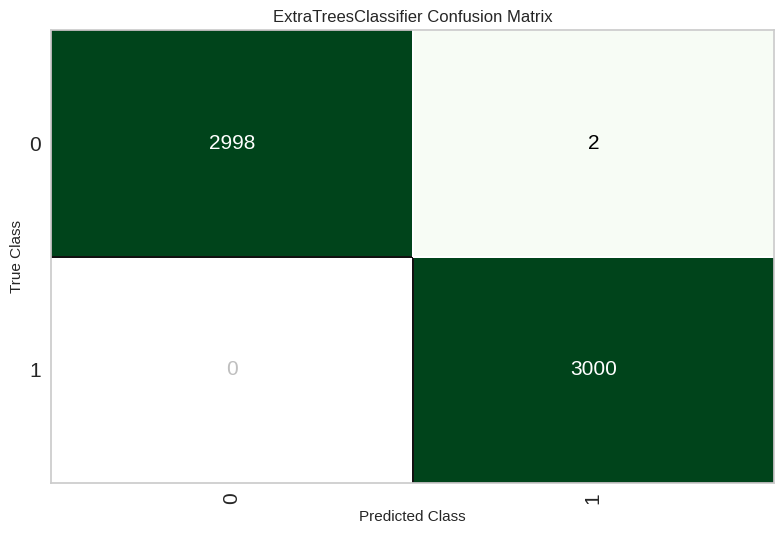

In [42]:
# plot confusion matrix
plot_model(best, plot = 'confusion_matrix')

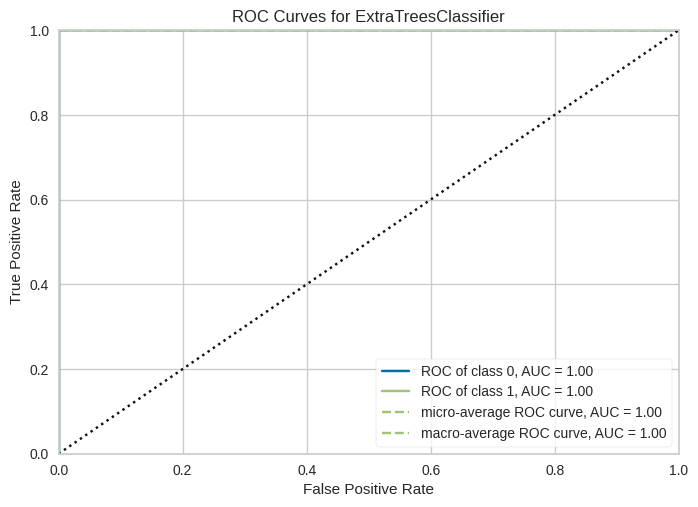

In [43]:
plot_model(best, plot = 'auc')

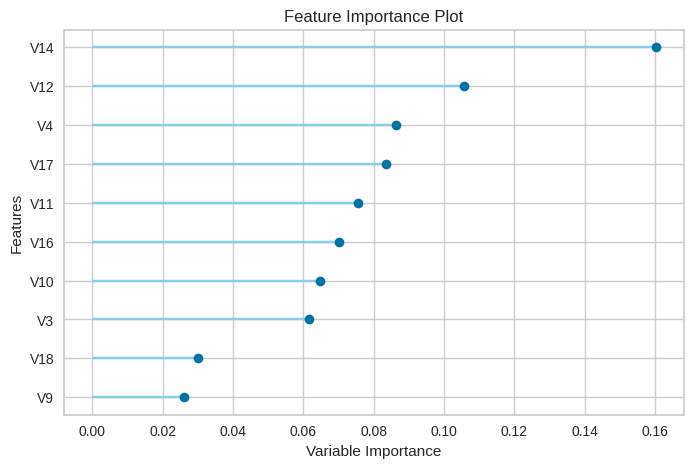

In [44]:
plot_model(best, plot = 'feature')

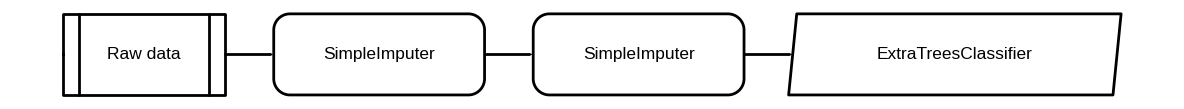

Generating PyCaret Plots:   6%|▌         | 1/17 [00:01<00:19,  1.21s/it]

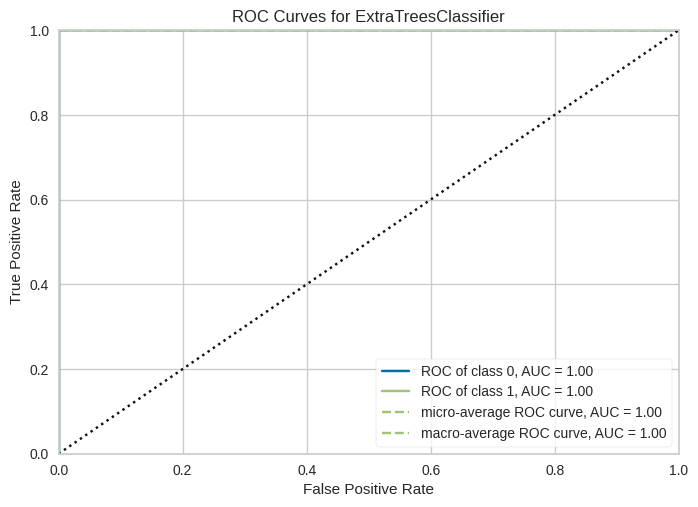

Generating PyCaret Plots:  12%|█▏        | 2/17 [00:02<00:21,  1.42s/it]

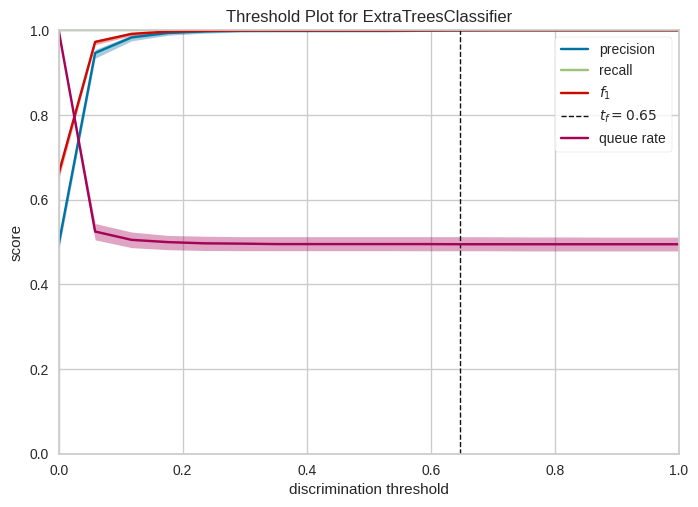

Generating PyCaret Plots:  18%|█▊        | 3/17 [00:48<05:02, 21.59s/it]

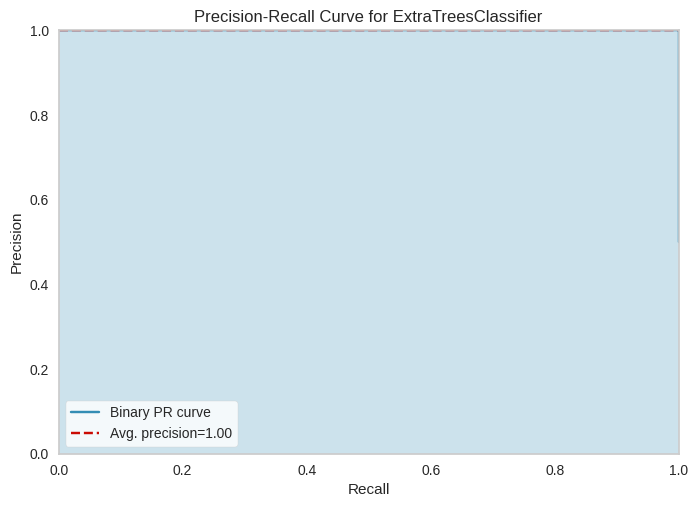

Generating PyCaret Plots:  24%|██▎       | 4/17 [00:49<02:54, 13.45s/it]

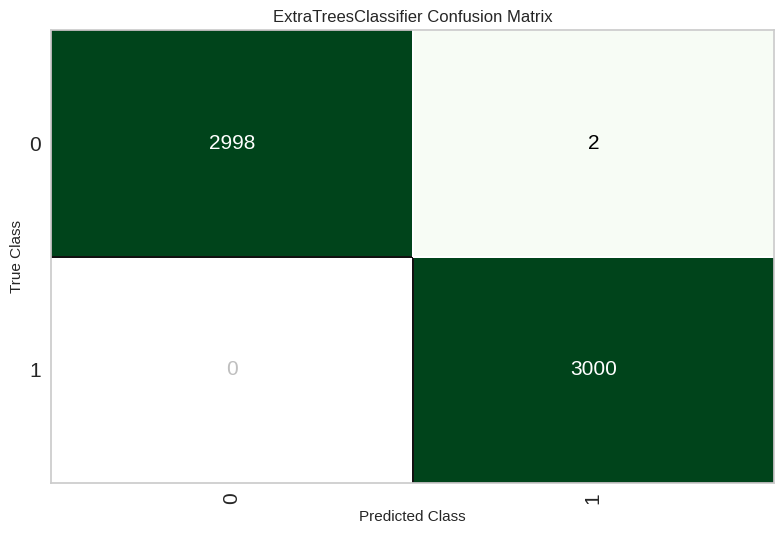

Generating PyCaret Plots:  29%|██▉       | 5/17 [00:50<01:47,  8.93s/it]

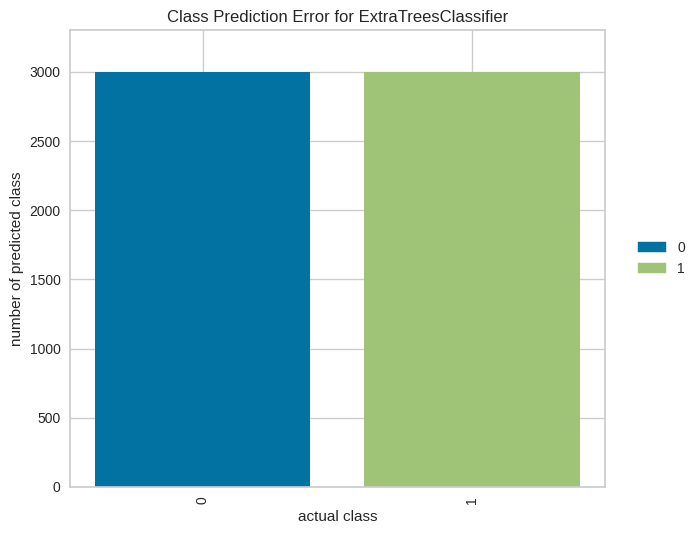

Generating PyCaret Plots:  35%|███▌      | 6/17 [00:51<01:08,  6.23s/it]

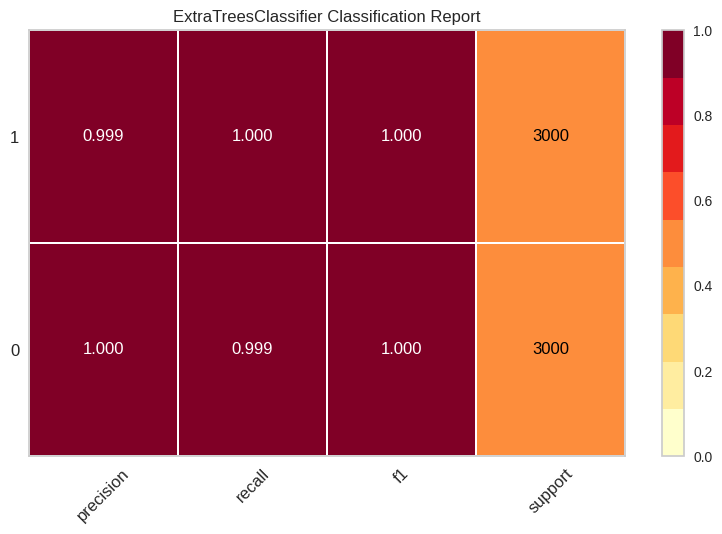

Generating PyCaret Plots:  41%|████      | 7/17 [00:52<00:45,  4.53s/it]

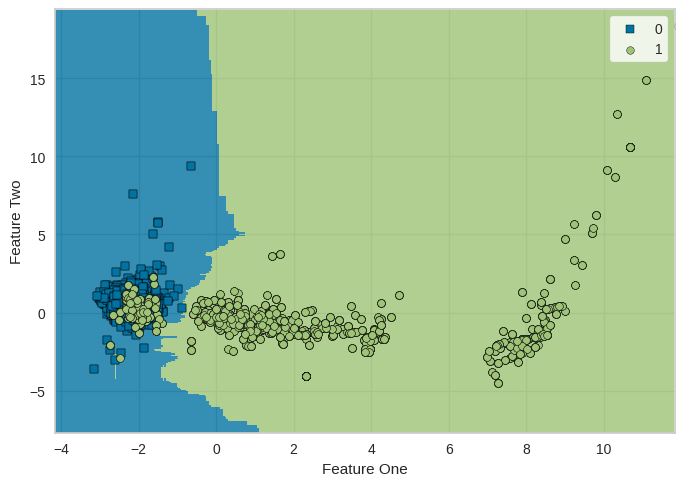

Generating PyCaret Plots:  47%|████▋     | 8/17 [00:55<00:35,  3.99s/it]

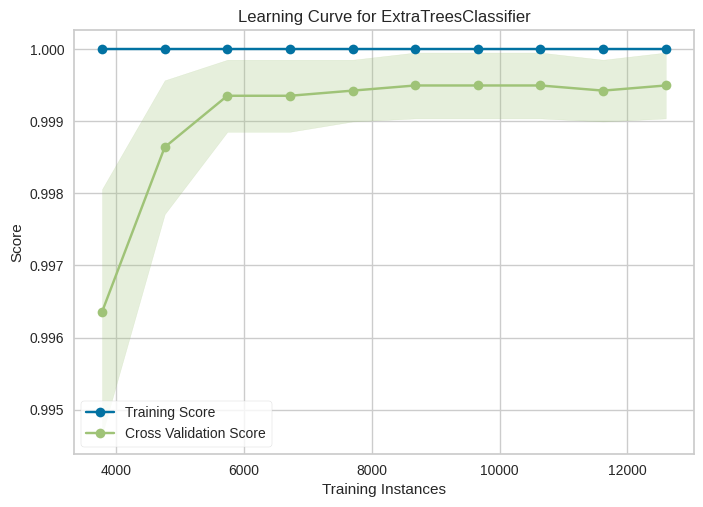

Generating PyCaret Plots:  53%|█████▎    | 9/17 [02:02<03:10, 23.82s/it]

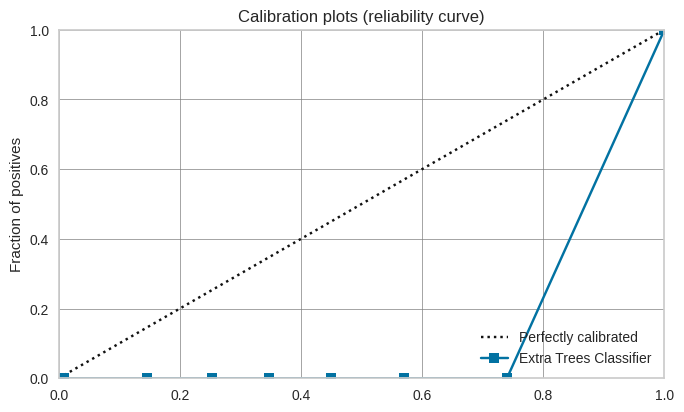

Generating PyCaret Plots:  59%|█████▉    | 10/17 [02:03<01:56, 16.71s/it]

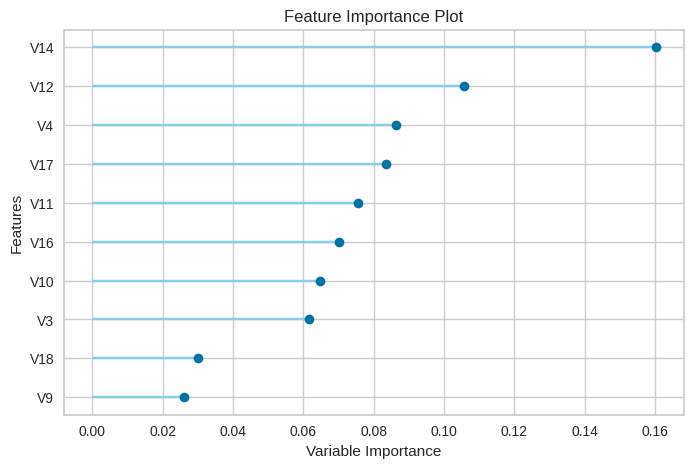

Generating PyCaret Plots:  65%|██████▍   | 11/17 [02:04<01:10, 11.82s/it]

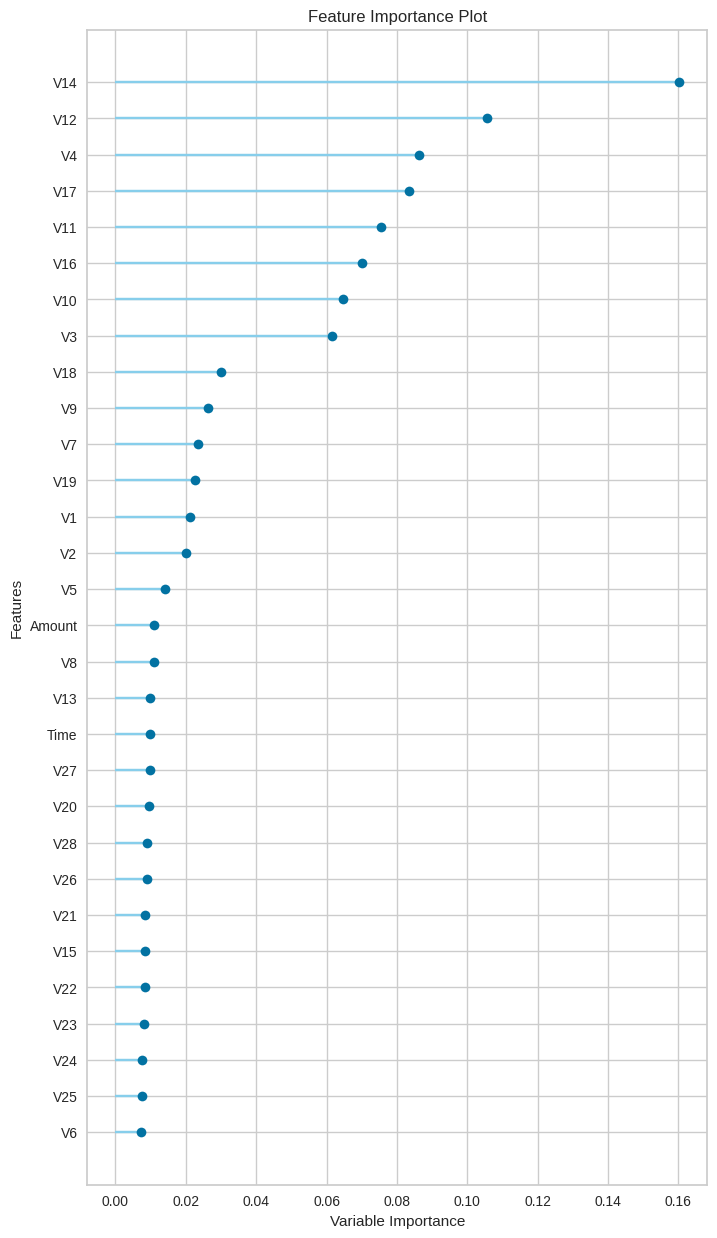

Generating PyCaret Plots:  71%|███████   | 12/17 [02:05<00:42,  8.57s/it]

,Parameters
bootstrap,False
ccp_alpha,0.0
class_weight,None
criterion,gini
max_depth,None
max_features,sqrt
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1


Generating PyCaret Plots:  76%|███████▋  | 13/17 [02:05<00:24,  6.14s/it]

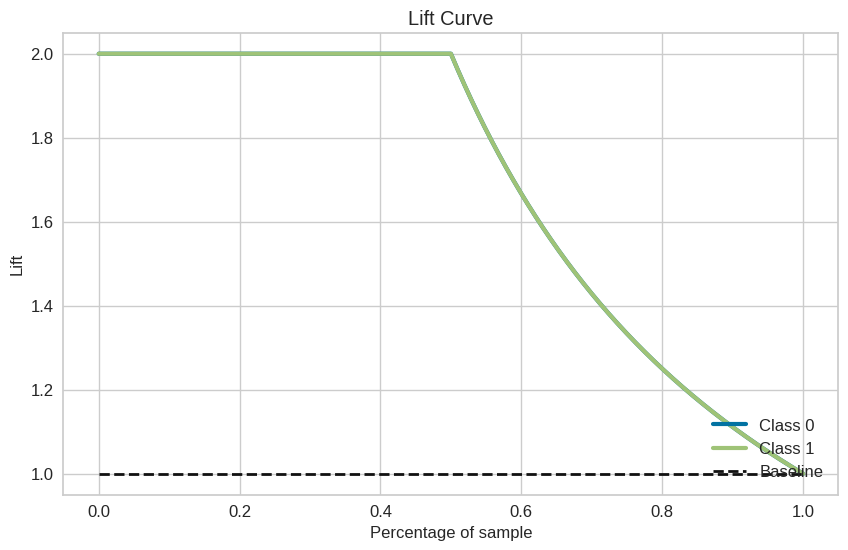

Generating PyCaret Plots:  82%|████████▏ | 14/17 [02:06<00:13,  4.60s/it]

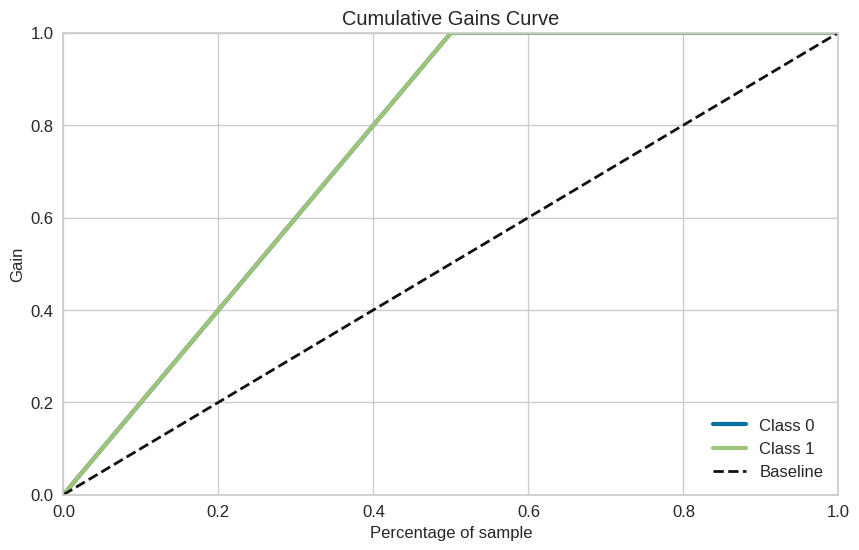

Generating PyCaret Plots:  88%|████████▊ | 15/17 [02:07<00:06,  3.45s/it]

Generating PyCaret Plots:  94%|█████████▍| 16/17 [02:09<00:02,  2.97s/it]

[✗] tree not available: 'NoneType' object has no attribute 'values'


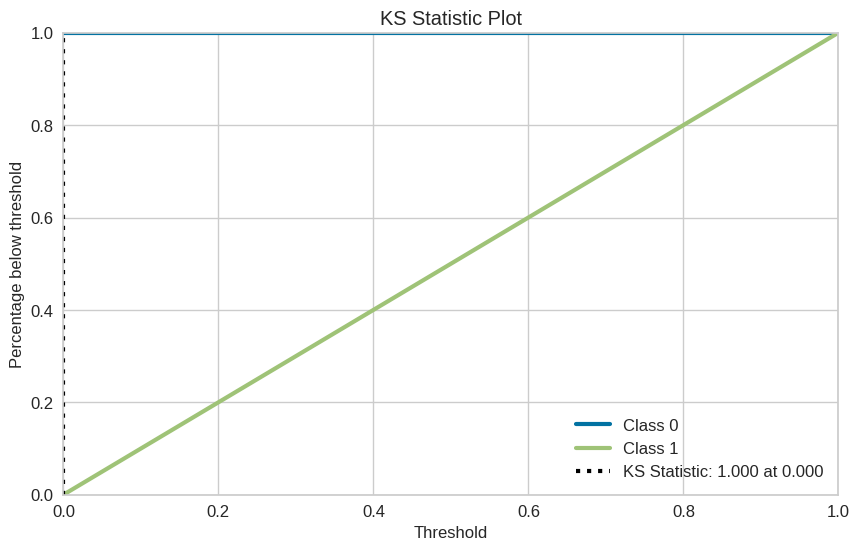

Generating PyCaret Plots: 100%|██████████| 17/17 [02:37<00:00,  9.26s/it]


In [50]:
from pycaret.classification import *
from tqdm import tqdm

plots = [
    'pipeline', 'auc', 'threshold', 'pr', 'confusion_matrix', 'error',
    'class_report', 'boundary',  'learning', 'calibration',
      'feature', 'feature_all', 'parameter', 'lift', 'gain',
    'tree', 'ks'
]

for plot_id in tqdm(plots, desc="Generating PyCaret Plots"):
    try:
        plot_model(best, plot=plot_id, save=False)  # set save=False if you only want to display
    except Exception as e:
        print(f"[✗] {plot_id} not available: {e}")


In [45]:
help(plot_model)

Help on function plot_model in module pycaret.classification.functional:

plot_model(estimator, plot: str = 'auc', scale: float = 1, save: bool = False, fold: Union[int, Any, NoneType] = None, fit_kwargs: Optional[dict] = None, plot_kwargs: Optional[dict] = None, groups: Union[str, Any, NoneType] = None, verbose: bool = True, display_format: Optional[str] = None) -> Optional[str]
    This function analyzes the performance of a trained model on holdout set.
    It may require re-training the model in certain cases.
    
    Example
    -------
    >>> from pycaret.datasets import get_data
    >>> juice = get_data('juice')
    >>> from pycaret.classification import *
    >>> exp_name = setup(data = juice,  target = 'Purchase')
    >>> lr = create_model('lr')
    >>> plot_model(lr, plot = 'auc')
    
    
    estimator: scikit-learn compatible object
        Trained model object
    
    
    plot: str, default = 'auc'
        List of available plots (ID - Name):
    
        * 'pipeline'